# Пункт f: Генерация выборки и построение доверительных интервалов

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

# Установка seed для воспроизводимости
np.random.seed(42)

# Параметры
n = 100  # объем выборки
beta = 0.95  # доверительная вероятность
theta_true = 22  # истинное значение параметра

# Генерация выборки из Uniform[θ, 2θ]
data = np.random.uniform(low=theta_true, high=2*theta_true, size=n)

# Выборочные характеристики
x_bar = np.mean(data)
x_max = np.max(data)
s2 = np.var(data, ddof=0)  # выборочная дисперсия

# Оценки параметра θ
theta_mom = 2/3 * x_bar  # метод моментов
theta_mle = (n + 1) / (2*n + 1) * x_max  # метод максимального правдоподобия

print(f"Истинное значение θ: {theta_true}")
print(f"Оценка ММ: θ̂_MM = {theta_mom:.4f}")
print(f"Оценка ММП: θ̂_MLE = {theta_mle:.4f}")

Истинное значение θ: 22
Оценка ММ: θ̂_MM = 21.5627
Оценка ММП: θ̂_MLE = 21.9645


## Точный доверительный интервал

In [2]:
# Точный ДИ на основе максимального элемента выборки
gamma_1 = ((1 + beta) / 2) ** (1/n)
gamma_2 = ((1 - beta) / 2) ** (1/n)

ci_exact_left = x_max / (gamma_1 + 1)
ci_exact_right = x_max / (gamma_2 + 1)
ci_exact_length = ci_exact_right - ci_exact_left

print("=" * 60)
print("ТОЧНЫЙ ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ")
print("=" * 60)
print(f"{ci_exact_left:.4f} < θ < {ci_exact_right:.4f}")
print(f"Длина интервала: {ci_exact_length:.4f}")
print(f"Содержит истинное значение: {ci_exact_left < theta_true < ci_exact_right}")

ТОЧНЫЙ ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ
21.8585 < θ < 22.2588
Длина интервала: 0.4003
Содержит истинное значение: True


## Асимптотический доверительный интервал (на основе ММ)

In [3]:
# Асимптотический ДИ для оценки метода моментов
z_critical = st.norm.ppf((1 + beta) / 2)
std_error = 2/3 * np.sqrt(s2 / n)

ci_asym_left = theta_mom - z_critical * std_error
ci_asym_right = theta_mom + z_critical * std_error
ci_asym_length = ci_asym_right - ci_asym_left

print("=" * 60)
print("АСИМПТОТИЧЕСКИЙ ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ (ММ)")
print("=" * 60)
print(f"{ci_asym_left:.4f} < θ < {ci_asym_right:.4f}")
print(f"Длина интервала: {ci_asym_length:.4f}")
print(f"Содержит истинное значение: {ci_asym_left < theta_true < ci_asym_right}")

АСИМПТОТИЧЕСКИЙ ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ (ММ)
20.7118 < θ < 22.4135
Длина интервала: 1.7018
Содержит истинное значение: True


# Пункт g: Бутстраповские доверительные интервалы

In [4]:
# Параметры бутстрапа
B = 1000  # число бутстраповских выборок

print(f"Число бутстраповских повторений: {B}")

Число бутстраповских повторений: 1000


## Бутстрап для оценки метода моментов

In [5]:
# Бутстрап для ММ
bootstrap_mom = np.zeros(B)
for i in range(B):
    sample = np.random.choice(data, size=n, replace=True)
    bootstrap_mom[i] = 2/3 * np.mean(sample)

# Процентильный метод
alpha = 1 - beta
ci_boot_mom_left = np.percentile(bootstrap_mom, 100 * alpha/2)
ci_boot_mom_right = np.percentile(bootstrap_mom, 100 * (1 - alpha/2))
ci_boot_mom_length = ci_boot_mom_right - ci_boot_mom_left

print("=" * 60)
print("БУТСТРАПОВСКИЙ ДИ (МЕТОД МОМЕНТОВ)")
print("=" * 60)
print(f"{ci_boot_mom_left:.4f} < θ < {ci_boot_mom_right:.4f}")
print(f"Длина интервала: {ci_boot_mom_length:.4f}")
print(f"Содержит истинное значение: {ci_boot_mom_left < theta_true < ci_boot_mom_right}")

БУТСТРАПОВСКИЙ ДИ (МЕТОД МОМЕНТОВ)
20.7401 < θ < 22.4289
Длина интервала: 1.6888
Содержит истинное значение: True


## Бутстрап для оценки максимального правдоподобия

In [6]:
# Бутстрап для ММП
bootstrap_mle = np.zeros(B)
for i in range(B):
    sample = np.random.choice(data, size=n, replace=True)
    bootstrap_mle[i] = (n + 1) / (2*n + 1) * np.max(sample)

# Процентильный метод
ci_boot_mle_left = np.percentile(bootstrap_mle, 100 * alpha/2)
ci_boot_mle_right = np.percentile(bootstrap_mle, 100 * (1 - alpha/2))
ci_boot_mle_length = ci_boot_mle_right - ci_boot_mle_left

print("=" * 60)
print("БУТСТРАПОВСКИЙ ДИ (МЕТОД МАКСИМАЛЬНОГО ПРАВДОПОДОБИЯ)")
print("=" * 60)
print(f"{ci_boot_mle_left:.4f} < θ < {ci_boot_mle_right:.4f}")
print(f"Длина интервала: {ci_boot_mle_length:.4f}")
print(f"Содержит истинное значение: {ci_boot_mle_left < theta_true < ci_boot_mle_right}")

БУТСТРАПОВСКИЙ ДИ (МЕТОД МАКСИМАЛЬНОГО ПРАВДОПОДОБИЯ)
21.7295 < θ < 21.9645
Длина интервала: 0.2350
Содержит истинное значение: False


# Пункт h: Сравнение всех доверительных интервалов

In [7]:
# Создание таблицы сравнения
intervals = {
    'Точный ДИ': {
        'left': ci_exact_left,
        'right': ci_exact_right,
        'length': ci_exact_length,
        'method': 'exact'
    },
    'Асимптотический (ММ)': {
        'left': ci_asym_left,
        'right': ci_asym_right,
        'length': ci_asym_length,
        'method': 'asymptotic'
    },
    'Бутстрап (ОМП)': {
        'left': ci_boot_mom_left,
        'right': ci_boot_mom_right,
        'length': ci_boot_mom_length,
        'method': 'bootstrap_mom'
    },
    'Бутстрап (ОММ)': {
        'left': ci_boot_mle_left,
        'right': ci_boot_mle_right,
        'length': ci_boot_mle_length,
        'method': 'bootstrap_mle'
    }
}

# Сортировка по длине интервала
sorted_intervals = sorted(intervals.items(), key=lambda x: x[1]['length'])

print("\n" + "=" * 70)
print("СРАВНЕНИЕ ДОВЕРИТЕЛЬНЫХ ИНТЕРВАЛОВ")
print("=" * 70)
print(f"{'Метод':<30} {'Длина':>10} {'Содержит θ':>15}")
print("-" * 70)

for rank, (name, ci) in enumerate(sorted_intervals, 1):
    contains = "✓" if ci['left'] < theta_true < ci['right'] else "✗"
    print(f"{rank}. {name:<27} {ci['length']:>10.4f} {contains:>15}")

print("=" * 70)
print(f"\nИстинное значение параметра: θ = {theta_true}")


СРАВНЕНИЕ ДОВЕРИТЕЛЬНЫХ ИНТЕРВАЛОВ
Метод                               Длина      Содержит θ
----------------------------------------------------------------------
1. Бутстрап (ОММ)                  0.2350               ✗
2. Точный ДИ                       0.4003               ✓
3. Бутстрап (ОМП)                  1.6888               ✓
4. Асимптотический (ММ)            1.7018               ✓

Истинное значение параметра: θ = 22


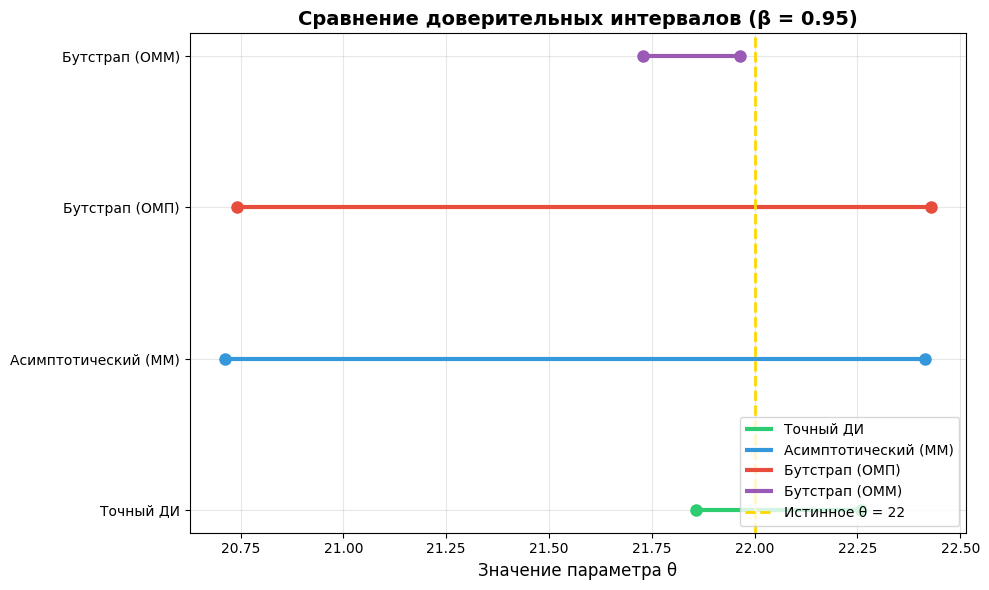

In [8]:
# Визуализация доверительных интервалов
fig, ax = plt.subplots(figsize=(10, 6))

y_positions = np.arange(len(intervals))
colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']

for i, (name, ci) in enumerate(intervals.items()):
    ax.hlines(y=i, xmin=ci['left'], xmax=ci['right'], 
              color=colors[i], linewidth=3, label=name)
    ax.plot(ci['left'], i, 'o', color=colors[i], markersize=8)
    ax.plot(ci['right'], i, 'o', color=colors[i], markersize=8)

# Вертикальная линия для истинного значения
ax.axvline(x=theta_true, color='gold', linestyle='--', 
           linewidth=2, label=f'Истинное θ = {theta_true}')

ax.set_yticks(y_positions)
ax.set_yticklabels(intervals.keys())
ax.set_xlabel('Значение параметра θ', fontsize=12)
ax.set_title('Сравнение доверительных интервалов (β = 0.95)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()